In [1]:
import warnings

warnings.filterwarnings('ignore')

In [2]:
# enhanced_consistent_plots.py
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ---------------------------
# Global style / constants
# ---------------------------
FIGSIZE = (6.685, 6.25)
DPI = 300

# Base font sizes (one place to change for the whole figure set)
BASE_FONTSIZE = 17  # base for axis labels and text
TITLE_FONTSIZE = 20  # titles
TICK_FONTSIZE = 17  # tick labels
ANNOT_FONTSIZE = 17  # annotation boxes/arrows
COLORBAR_FONTSIZE = 17  # colorbar label & ticks
MATH_FONTSIZE = 18  # math text inside figures

MARKER_SIZE = 36  # scatter marker size (consistent)
ALPHA = 0.6  # scatter alpha
GRID_STYLE = {"linestyle": "--", "alpha": 0.3, "linewidth": 0.8}

# Set global style
plt.style.use('seaborn-v0_8-whitegrid')
colors = sns.color_palette("coolwarm", as_cmap=True)
if isinstance(colors, LinearSegmentedColormap):
    CMAP = colors
else:
    CMAP = LinearSegmentedColormap.from_list(name="custom_cmap", colors=colors)
# Define colors for consistency (academic-friendly palette)
primary_color = '#2E86AB'  # Professional blue
secondary_color = '#A23B72'  # Sophisticated purple
accent_color = '#F18F01'  # Warm orange
grid_color = '#E5E5E5'  # Light gray
success_color = '#27AE60'  # Green for positive indicators
warning_color = '#F39C12'  # Orange for warnings
danger_color = '#E74C3C'  # Red for critical areas
neutral_color = '#95A5A6'  # Gray for neutral elements

# Vulnerability level colors (for SVI-specific plots)
VULNERABILITY_COLORS = {
    'low': '#27AE60',  # Green
    'moderate': '#F39C12',  # Orange
    'high': '#E67E22',  # Dark orange
    'very_high': '#E74C3C'  # Red
}

# Apply consistent rcParams so all figures match
plt.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "savefig.dpi": DPI,
    "font.family": "DejaVu Sans",  # widely available, readable
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "legend.fontsize": BASE_FONTSIZE,
    "mathtext.fontset": "dejavusans",  # make LaTeX/math text render consistently
    "axes.grid": False,  # we'll call grid(...) explicitly
    "axes.spines.top": False,  # Remove top spine for cleaner look
    "axes.spines.right": False,  # Remove right spine
    "axes.linewidth": 1.2,  # Slightly thicker axes
    "grid.linewidth": 0.5,  # Consistent grid thickness
    "lines.linewidth": 2.0,  # Default line thickness
    "patch.linewidth": 1.0,  # Box plot lines
    "boxplot.flierprops.markersize": 4,  # Outlier marker size
    "figure.facecolor": 'white',  # White background
    "axes.facecolor": 'white',  # White axes background
    "savefig.facecolor": 'white',  # White saved figure background
    "text.usetex": False,  # Disable LaTeX for compatibility
})


# Utility functions for consistent plotting

def setup_academic_grid(ax, axis='both'):
    """Apply consistent grid styling to axes"""
    ax.grid(True, axis=axis, linestyle=":", linewidth=0.5,
            color=grid_color, alpha=0.7)


def add_vulnerability_zones(ax, axis='x', alpha=0.1):
    """Add vulnerability level background zones for SVI plots"""
    if axis == 'x':
        ax.axvspan(0, 0.25, alpha=alpha, color=VULNERABILITY_COLORS['low'], label='Low Vulnerability')
        ax.axvspan(0.25, 0.50, alpha=alpha, color=VULNERABILITY_COLORS['moderate'], label='Moderate Vulnerability')
        ax.axvspan(0.50, 0.75, alpha=alpha, color=VULNERABILITY_COLORS['high'], label='High Vulnerability')
        ax.axvspan(0.75, 1, alpha=alpha, color=VULNERABILITY_COLORS['very_high'], label='Very High Vulnerability')
    elif axis == 'y':
        ax.axhspan(0, 0.25, alpha=alpha, color=VULNERABILITY_COLORS['low'])
        ax.axhspan(0.25, 0.50, alpha=alpha, color=VULNERABILITY_COLORS['moderate'])
        ax.axhspan(0.50, 0.75, alpha=alpha, color=VULNERABILITY_COLORS['high'])
        ax.axhspan(0.75, 1, alpha=alpha, color=VULNERABILITY_COLORS['very_high'])


def style_boxplot(box_plot, primary=primary_color, secondary=secondary_color):
    """Apply consistent styling to boxplot elements"""
    for patch in box_plot['boxes']:
        patch.set_facecolor(primary)
        patch.set_alpha(0.7)
        patch.set_linewidth(1.5)

    for element in ['whiskers', 'caps']:
        for item in box_plot[element]:
            item.set_color(primary)
            item.set_linewidth(1.5)

    for median in box_plot['medians']:
        median.set_color('white')
        median.set_linewidth(2)

    for flier in box_plot['fliers']:
        flier.set_markerfacecolor(secondary)
        flier.set_markeredgecolor(secondary)
        flier.set_markersize(4)
        flier.set_alpha(0.6)


def add_statistical_annotations(ax, data, position=1, orientation='horizontal'):
    """Add statistical annotations to plots"""
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    mean_val = data.mean()

    if orientation == 'horizontal':
        ax.text(median, position + 0.15, f'Median: {median:.3f}',
                ha='center', va='bottom', fontsize=ANNOT_FONTSIZE - 2,
                fontweight='bold', color=primary_color)
        ax.text(mean_val, position - 0.15, f'Mean: {mean_val:.3f}',
                ha='center', va='top', fontsize=ANNOT_FONTSIZE - 2,
                fontweight='bold', color=accent_color)


def format_academic_title(title, subtitle=None):
    """Format titles consistently for academic papers"""
    if subtitle:
        return f"{title}\n{subtitle}"
    return title


# Utility to save figures with tight layout and a standardized filename
def savefig_standard(fname, dpi=None):
    """Save figure with consistent academic formatting"""
    if dpi is None:
        dpi = DPI
    plt.tight_layout()
    plt.savefig(fname, bbox_inches="tight", dpi=dpi, facecolor='white',
                edgecolor='none', transparent=False)
    print(f"Saved: {fname}")


def create_academic_legend(ax, title=None, loc='best'):
    """Create consistently styled legend"""
    legend = ax.legend(title=title, loc=loc, frameon=True, fancybox=True,
                       shadow=True, framealpha=0.9, facecolor='white',
                       edgecolor=grid_color, fontsize=BASE_FONTSIZE - 2)
    if title:
        legend.get_title().set_fontsize(BASE_FONTSIZE - 1)
        legend.get_title().set_fontweight('bold')
    return legend


# Statistical summary function
def print_statistical_summary(data, variable_name="Variable"):
    """Print comprehensive statistical summary"""
    print("=" * 80)
    print(f"{variable_name.upper()} - STATISTICAL ANALYSIS REPORT")
    print("=" * 80)
    print()

    print("DESCRIPTIVE STATISTICS:")
    print(f"• Sample Size: {len(data):,}")
    print(f"• Mean: {data.mean():.4f}")
    print(f"• Median: {np.median(data):.4f}")
    print(f"• Standard Deviation: {data.std():.4f}")
    print(f"• Variance: {data.var():.4f}")
    print(f"• Range: {data.max() - data.min():.4f}")
    print(f"• Interquartile Range: {np.percentile(data, 75) - np.percentile(data, 25):.4f}")
    print(f"• Coefficient of Variation: {data.std() / data.mean():.4f}")
    print()

    print("DISTRIBUTION CHARACTERISTICS:")
    skewness = stats.skew(data)
    kurtosis_val = stats.kurtosis(data)
    print(
        f"• Skewness: {skewness:.4f} ({'Right-skewed' if skewness > 0.5 else 'Left-skewed' if skewness < -0.5 else 'Approximately symmetric'})")
    print(f"• Kurtosis: {kurtosis_val:.4f} ({'Heavy-tailed' if kurtosis_val > 0 else 'Light-tailed'})")
    print()

In [3]:
def load_agent_traces():
    """
    Load all agent traces from CSV files with robust coordinate handling.

    Returns:
        dict: Dictionary with agent IDs as keys and their path data as values
    """
    print("Loading agent traces...")

    # Read agent IDs from statistics file
    try:
        agents_ids = pl.Series(
            pl.read_csv("simulation_outcomes/Agents_Statistics_Trial.csv").select(
                "agent_id"
            )
        ).to_list()
    except Exception as e:
        print(f"Error reading agent statistics: {e}")
        return {}

    agent_traces = {}
    traces_loaded = 0
    coordinate_issues = 0
    all_entries = os.listdir("simulation_outcomes/agents_traces")
    print(all_entries)
    for ag in all_entries:
        try:
            trace_file = f"simulation_outcomes/agents_traces/{ag}"
            if not os.path.exists(trace_file):
                print(f"Trace file not found for agent {ag}")
                continue

            df = pl.read_csv(trace_file)

            if df.is_empty():
                print(f"Empty trace file for agent {ag}")
                continue

            # debug first trace structure
            if traces_loaded == 0:
                print(f"\nDEBUG - First agent ({ag}) data structure:")
                print(f"Columns: {df.columns}")
                print(f"Shape: {df.shape}")
                print("First 3 rows:")
                print(df.head(3))

            # We expect columns 'x' and 'y' but their semantics may be swapped.
            if "x" not in df.columns or "y" not in df.columns:
                print(f"Missing x/y columns for agent {ag}, skipping")
                continue

            # Take first non-null sample values to determine which column is lat/lon
            sample_x = None
            sample_y = None
            try:
                sample_x = float(df.select("x").drop_nulls().to_series()[0])
                sample_y = float(df.select("y").drop_nulls().to_series()[0])
            except Exception:
                # fallback to iter_rows if above fails
                for r in df.select(["x", "y"]).iter_rows():
                    if r[0] is not None and r[1] is not None:
                        sample_x = float(r[0])
                        sample_y = float(r[1])
                        break

            if sample_x is None or sample_y is None:
                print(f"No sample coordinates for agent {ag}, skipping")
                continue

            # Heuristic: lat values for Paris should be ~48.x, lon ~1..4
            # Determine which column is lat and which is lon
            if 40 <= sample_x <= 55 and -20 <= sample_y <= 20:
                # x looks like latitude, y looks like longitude
                lat_col, lon_col = "x", "y"
            elif 40 <= sample_y <= 55 and -20 <= sample_x <= 20:
                # y is latitude, x is longitude (the common case)
                lat_col, lon_col = "y", "x"
            else:
                # Unknown: fall back to assumption that y is lat and x is lon,
                # but print a warning so you can inspect.
                lat_col, lon_col = "y", "x"
                print(
                    f"Warning: Could not confidently determine lat/lon columns for agent {ag}. "
                    f"Sample values: x={sample_x}, y={sample_y}. Assuming {lat_col}=lat, {lon_col}=lon."
                )

            # Select coordinates with determined order
            coordinates_df = df.select([lat_col, lon_col]).drop_nulls()
            if coordinates_df.is_empty():
                print(
                    f"No valid coordinates for agent {ag} after selecting {lat_col},{lon_col}"
                )
                continue

            coordinates = []
            for row in coordinates_df.iter_rows():
                lat, lon = float(row[0]), float(row[1])  # now row[0]=lat, row[1]=lon
                # Validate numeric
                if not (abs(lat) < 1e6 and abs(lon) < 1e6):
                    coordinate_issues += 1
                    if coordinate_issues <= 5:
                        print(
                            f"Invalid numeric coords for agent {ag}: lat={lat}, lon={lon}"
                        )
                    continue

                coordinates.append([lat, lon])  # Folium expects [lat, lon]

            if len(coordinates) >= 2:
                agent_traces[ag] = coordinates
                traces_loaded += 1
                if traces_loaded == 1:
                    print(f"DEBUG - Agent {ag} coordinates sample:")
                    print(f"  Sample lat,lon first point: {coordinates[0]} (lat, lon)")
                    print(f"  Sample lat,lon last point: {coordinates[-1]} (lat, lon)")
                    print(f"  Path length: {len(coordinates)} points")
            else:
                print(
                    f"Agent {ag}: insufficient valid coordinates ({len(coordinates)} points)"
                )

        except Exception as e:
            print(f"Error loading trace for agent {ag}: {e}")

    print(f"\nSUMMARY:")
    print(
        f"Successfully loaded traces for {traces_loaded} out of {len(agents_ids)} agents"
    )
    print(f"Coordinate issues found: {coordinate_issues}")
    return agent_traces


In [8]:
from typing import Dict
import polars as pl
import os


def i_need_real_agent_id(agent_csv_naming: str) -> str:
    return "_".join(agent_csv_naming.strip().replace(".csv", "").split("_")[:-1])


def load_simulation_data():
    """Load all simulation outcome data"""
    print("Loading simulation data...")

    # Load agent summary statistics
    agent_summary = pl.read_csv("simulation_outcomes/Agents_Statistics_Trial.csv")

    # Load journey segment details
    journey_segments = pl.read_csv("simulation_outcomes/Journey_Segments_Detail.csv")

    # Load agent traces (dict of DataFrames)
    agent_traces: Dict[str, pl.DataFrame] = {}
    all_entries = os.listdir("simulation_outcomes/agents_traces")

    for entry in all_entries:
        df = pl.read_csv(f"simulation_outcomes/agents_traces/{entry}")
        last_row = df.row(-1, named=True)

        if last_row["using_public_transport"] and last_row["mode"] in ["WALKING", "BIKE"]:
            # update `final_mode` where agent_id matches
            agent_id = i_need_real_agent_id(entry)

            agent_summary = agent_summary.with_columns(
                pl.when(pl.col("agent_id") == agent_id)
                .then(pl.lit("public_transport"))  # ✅ literal string, not a column
                .otherwise(pl.col("final_mode"))
                .alias("final_mode")
            )

        agent_traces[entry.replace(".csv", "")] = df
        del df

    return agent_summary, journey_segments, agent_traces


# Load the data
agent_summary, journey_segments, agent_traces = load_simulation_data()

Loading simulation data...


In [15]:
def preprocess_data(agent_summary: pl.DataFrame, journey_segments: pl.DataFrame):
    """Clean and preprocess the data for analysis"""

    # Convert SVI to categorical vulnerability levels
    labels = ["low", "moderate", "high", "very_high"]

    agent_summary = agent_summary.with_columns(
        pl.col("svi")
        .qcut(4)
        .to_physical()  # convert categorical to underlying integers
        .map_elements(lambda x: labels[x], return_dtype=pl.Utf8)
        .alias("vulnerability_level")
    )

    # Convert evacuation time to minutes if needed
    if "evacuation_time_seconds" in agent_summary.columns:
        agent_summary = agent_summary.with_columns(
            (pl.col("evacuation_time_seconds") / 60).alias("evacuation_time_minutes")
        )

    # Extract mode information
    agent_summary = agent_summary.with_columns(
        pl.col("final_mode").alias("mode_category")
    )

    # Categorize success
    agent_summary = agent_summary.with_columns(
        (pl.col("status") == "ARRIVED").alias("success")
    )

    return agent_summary, journey_segments


agent_summary, journey_segments = preprocess_data(agent_summary, journey_segments)

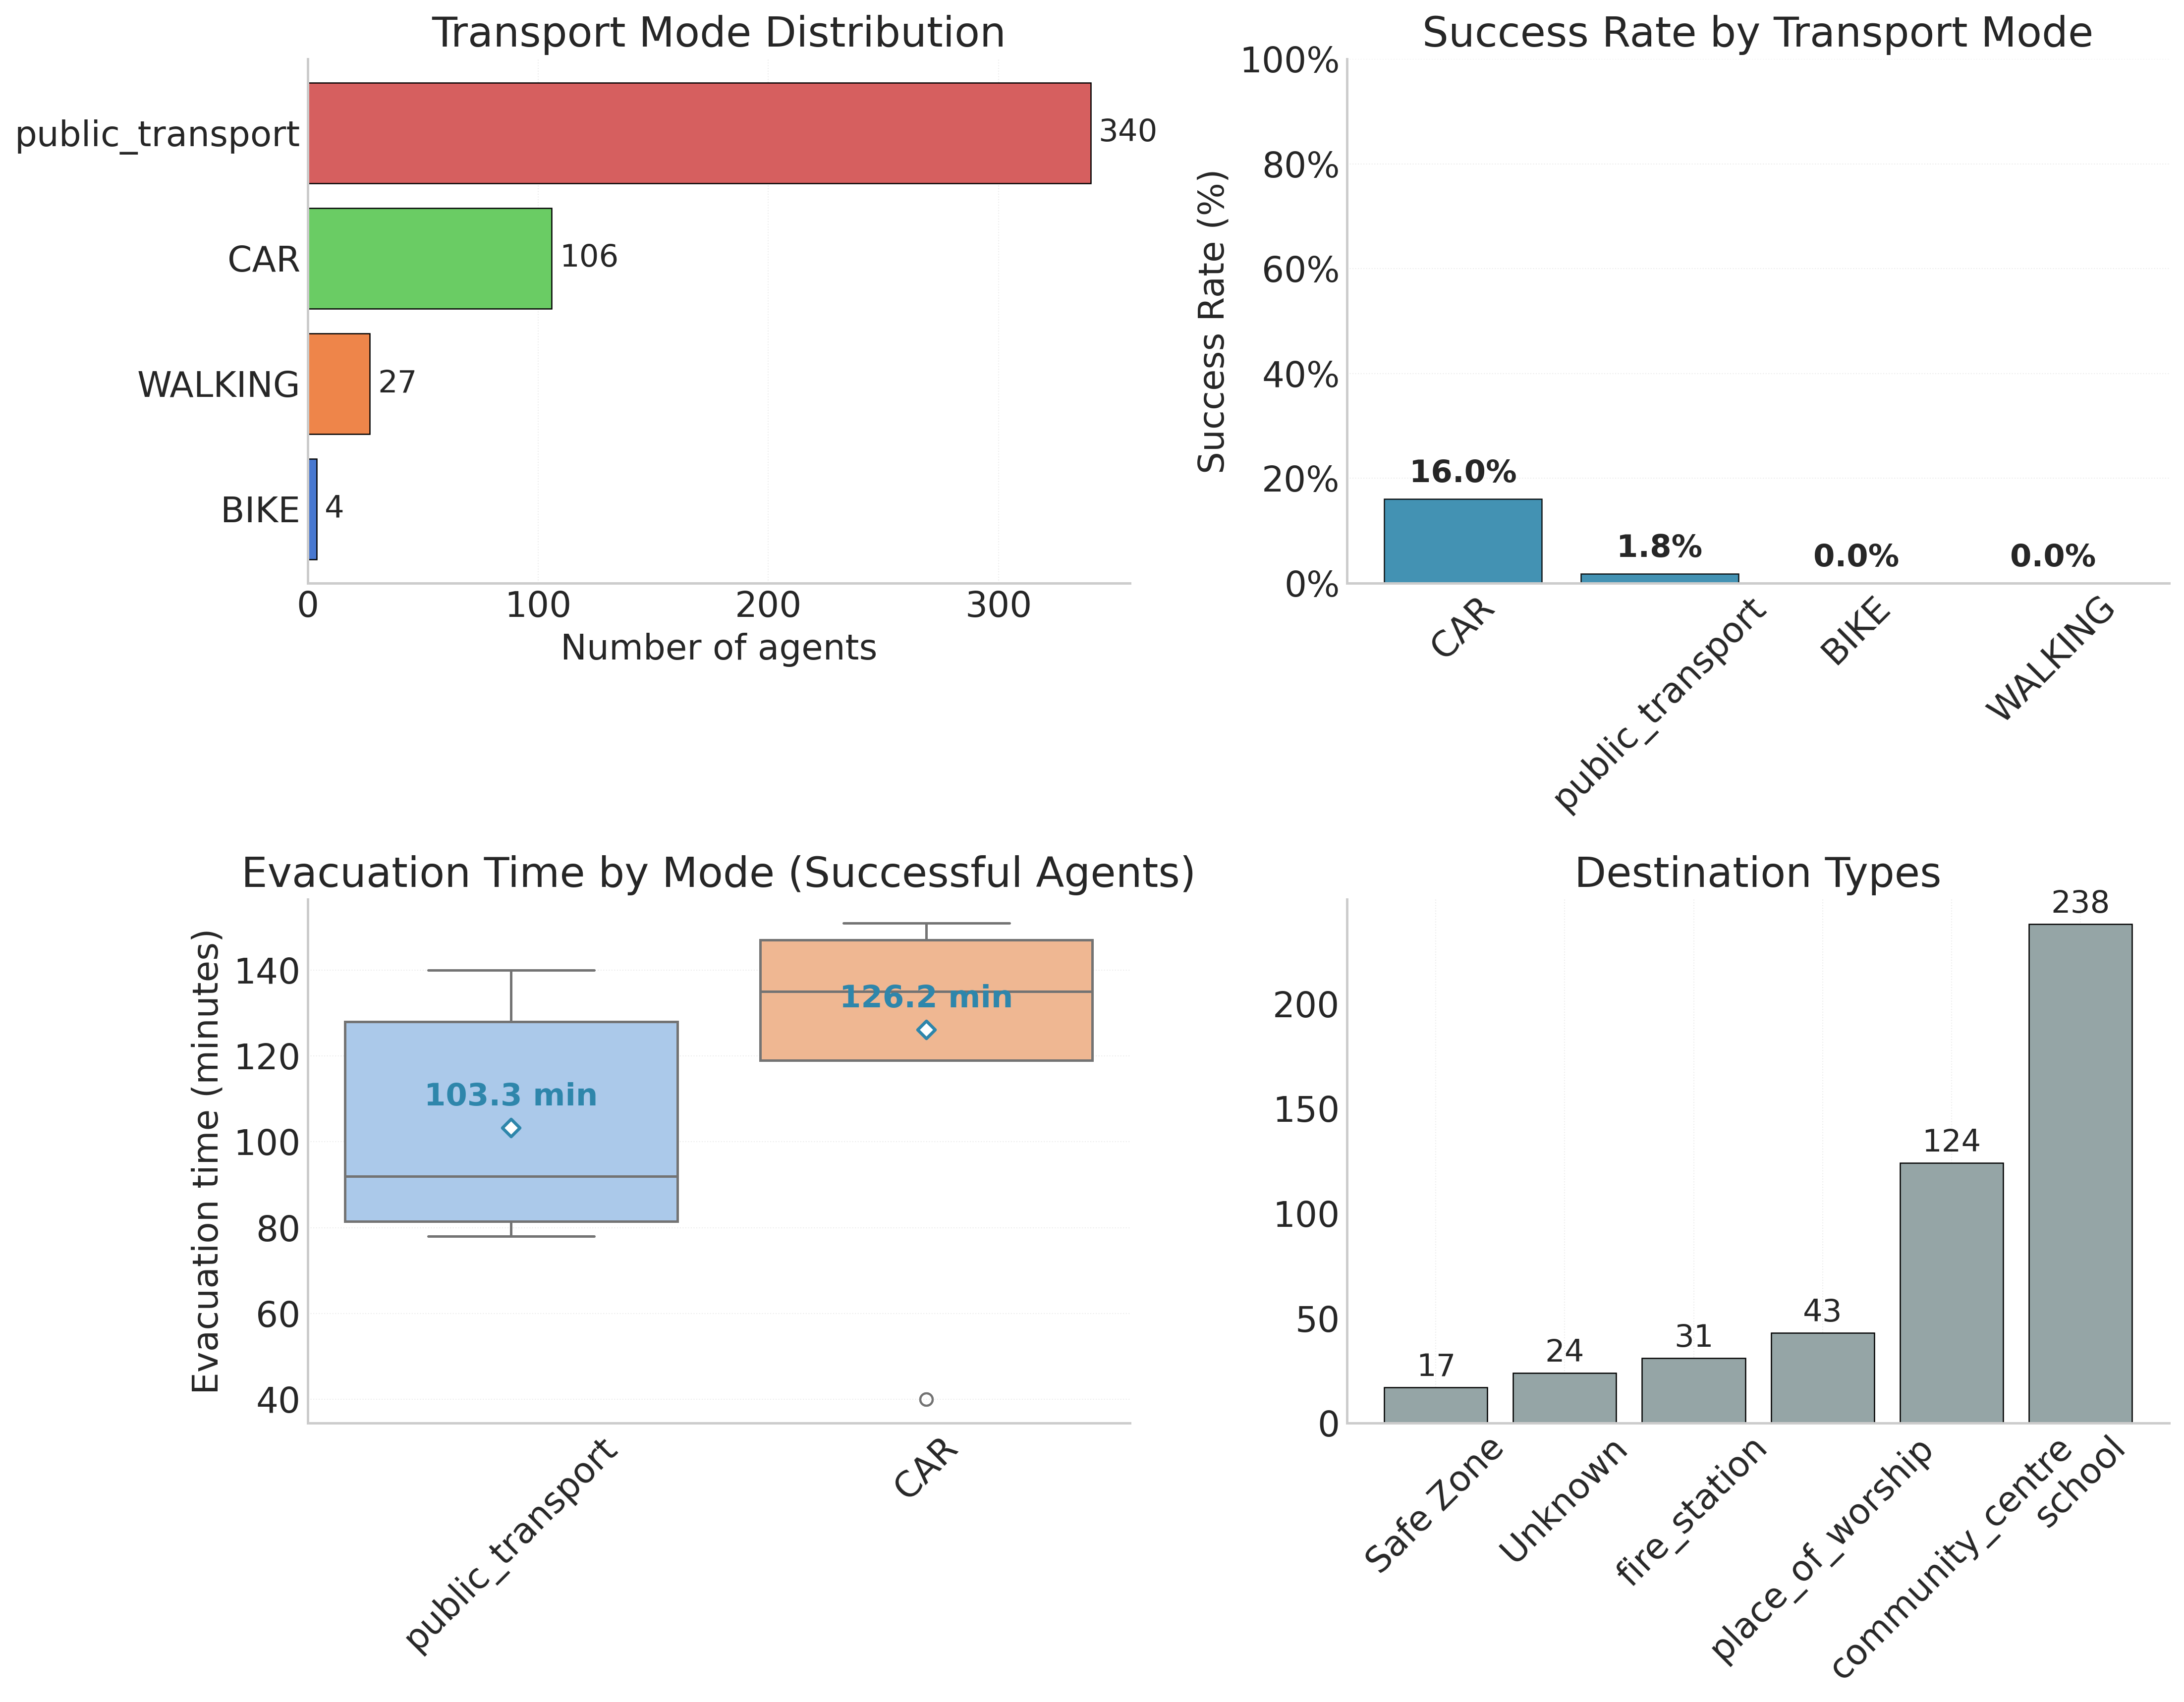

In [24]:

import polars as pl
from typing import Optional


def plot_overall_evacuation_stats(agent_summary: pl.DataFrame,
                                  save_path: Optional[str] = None,
                                  force_percent_ylim: bool = False):
    """
    Create cleaned, publication-ready visualizations for overall evacuation statistics.
    - agent_summary can be a Polars DataFrame or a pandas DataFrame.
    - save_path: optional path to save the figure (uses savefig_standard for consistent formatting).
    - force_percent_ylim: if True, the success-rate axes will be fixed to 0-100%.
    Returns (fig, axes).
    """

    # --- convert Polars -> pandas if necessary ---
    if isinstance(agent_summary, pl.DataFrame):
        df = agent_summary.to_pandas()
    else:
        df = agent_summary.copy()

    # Basic safety/guard clauses
    if df.shape[0] == 0:
        raise ValueError("agent_summary is empty")

    # Create figure grid (2x2)
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # ---------- Plot 1: Mode distribution (horizontal bar, paper-friendly) ----------
    ax = axes[0, 0]
    if "final_mode" in df.columns:
        mode_counts = df['final_mode'].value_counts().sort_values()  # ascending for nicer horizontal bars
        colors = sns.color_palette("muted", len(mode_counts))
        ax.barh(mode_counts.index, mode_counts.values, color=colors, edgecolor='k', linewidth=0.6)
        ax.set_title("Transport Mode Distribution", fontsize=TITLE_FONTSIZE)
        ax.set_xlabel("Number of agents")
        # annotate counts
        for i, (label, val) in enumerate(mode_counts.items()):
            ax.text(val + max(mode_counts.values) * 0.01, i, f"{val:,}", va='center', fontsize=BASE_FONTSIZE - 2)
    else:
        ax.text(0.5, 0.5, "No 'final_mode' column", ha='center', va='center', fontsize=BASE_FONTSIZE)
        ax.set_axis_off()

    setup_academic_grid(ax, axis='x')

    # ---------- Plot 2: Success rate by mode (percent, annotated) ----------
    ax = axes[0, 1]
    if "final_mode" in df.columns and "success" in df.columns:
        success_by_mode = df.groupby('final_mode')['success'].agg(['mean', 'count'])
        success_by_mode['mean_pct'] = success_by_mode['mean'] * 100  # percentage

        # Sort by mean_pct descending for visual clarity
        success_by_mode = success_by_mode.sort_values('mean_pct', ascending=False)

        bars = ax.bar(success_by_mode.index, success_by_mode['mean_pct'],
                      edgecolor='k', linewidth=0.6, alpha=0.9)

        # Color bars using your vulnerability palette or default
        for bar in bars:
            bar.set_facecolor(primary_color)

        ax.set_title("Success Rate by Transport Mode", fontsize=TITLE_FONTSIZE)
        ax.set_ylabel("Success Rate (%)")
        ax.tick_params(axis='x', rotation=45)

        # Set y-axis formatter to percent-like labels
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0))

        # Optionally force 0-100% axis
        if force_percent_ylim:
            ax.set_ylim(0, 100)
        else:
            # Give a little headroom above the max for annotations
            top = success_by_mode['mean_pct'].max() * 1.12
            ax.set_ylim(0, max(5, top))

        # annotate each bar with "X.X% (n=N)"
        for i, (mode, row) in enumerate(success_by_mode.iterrows()):
            pct = row['mean_pct']
            n = int(row['count'])
            ax.text(i, pct + (ax.get_ylim()[1] * 0.02), f"{pct:.1f}%",
                    ha='center', va='bottom', fontsize=BASE_FONTSIZE - 2, fontweight='bold')
    else:
        ax.text(0.5, 0.5, "Need 'final_mode' and 'success' columns", ha='center', va='center', fontsize=BASE_FONTSIZE)
        ax.set_axis_off()

    setup_academic_grid(ax, axis='y')

    # ---------- Plot 3: Evacuation time distribution by mode (successful agents only), show means ----------
    ax = axes[1, 0]
    if 'evacuation_time_minutes' in df.columns and 'success' in df.columns and 'final_mode' in df.columns:
        successful = df[df['success'].astype(bool)].copy()

        # order modes by median evacuation time (nice ordering)
        order = successful.groupby('final_mode')['evacuation_time_minutes'].median().sort_values().index.tolist()

        # draw the boxplot
        sns.boxplot(
            data=successful,
            x='final_mode',
            y='evacuation_time_minutes',
            order=order,
            ax=ax,
            showfliers=True,
            linewidth=1.2,
            palette='pastel'
        )

        ax.set_title('Evacuation Time by Mode (Successful Agents)', fontsize=TITLE_FONTSIZE)
        ax.set_xlabel('')
        ax.set_ylabel('Evacuation time (minutes)')
        ax.tick_params(axis='x', rotation=45)
        setup_academic_grid(ax, axis='y')

        # --- compute group means and overlay ---
        # means in same order as 'order'
        means_series = successful.groupby('final_mode')['evacuation_time_minutes'].mean().reindex(order)
        means = means_series.values

        # x positions for categorical ticks (0..n-1)
        x_positions = np.arange(len(order))

        # Plot mean markers (diamond) on top of the boxes
        ax.scatter(
            x_positions,
            means,
            marker='D',  # diamond marker
            s=MARKER_SIZE,  # consistent marker size global
            edgecolor=primary_color,  # colored edge
            facecolor='white',  # white fill for contrast
            linewidth=1.5,
            zorder=10
        )

        # Annotate mean values above each marker
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        for i, m in enumerate(means):
            ax.text(
                x_positions[i],
                m + y_range * 0.03,  # little above the mean marker (3% of y-range)
                f"{m:.1f} min",
                ha='center',
                va='bottom',
                fontsize=BASE_FONTSIZE - 2,
                fontweight='bold',
                color=primary_color
            )

    else:
        ax.text(0.5, 0.5, "Need 'evacuation_time_minutes', 'success' and 'final_mode' columns",
                ha='center', va='center', fontsize=BASE_FONTSIZE)
        ax.set_axis_off()

    # ---------- Plot 4: Destination types (bar) ----------
    ax = axes[1, 1]
    if 'target_destination_type' in df.columns:
        dest_counts = df['target_destination_type'].value_counts().sort_values()
        ax.bar(dest_counts.index, dest_counts.values, color=neutral_color, edgecolor='k', linewidth=0.6)
        ax.set_title('Destination Types', fontsize=TITLE_FONTSIZE)
        ax.tick_params(axis='x', rotation=45)
        setup_academic_grid(ax, axis='x')
        # annotate counts
        for i, (label, val) in enumerate(dest_counts.items()):
            ax.text(i, val + max(dest_counts.values) * 0.01, f"{val:,}", ha='center', va='bottom',
                    fontsize=BASE_FONTSIZE - 2)
    else:
        ax.text(0.5, 0.5, "No 'target_destination_type' column", ha='center', va='center', fontsize=BASE_FONTSIZE)
        ax.set_axis_off()

    # Tight layout and adjust spacing
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    # Optional save
    if save_path:
        try:
            savefig_standard(save_path)
        except Exception:
            # fallback to plain save
            plt.savefig(save_path, bbox_inches='tight', dpi=DPI)
            print(f"Saved (fallback): {save_path}")

    return fig, axes


fig, axes = plot_overall_evacuation_stats(agent_summary, force_percent_ylim=True)

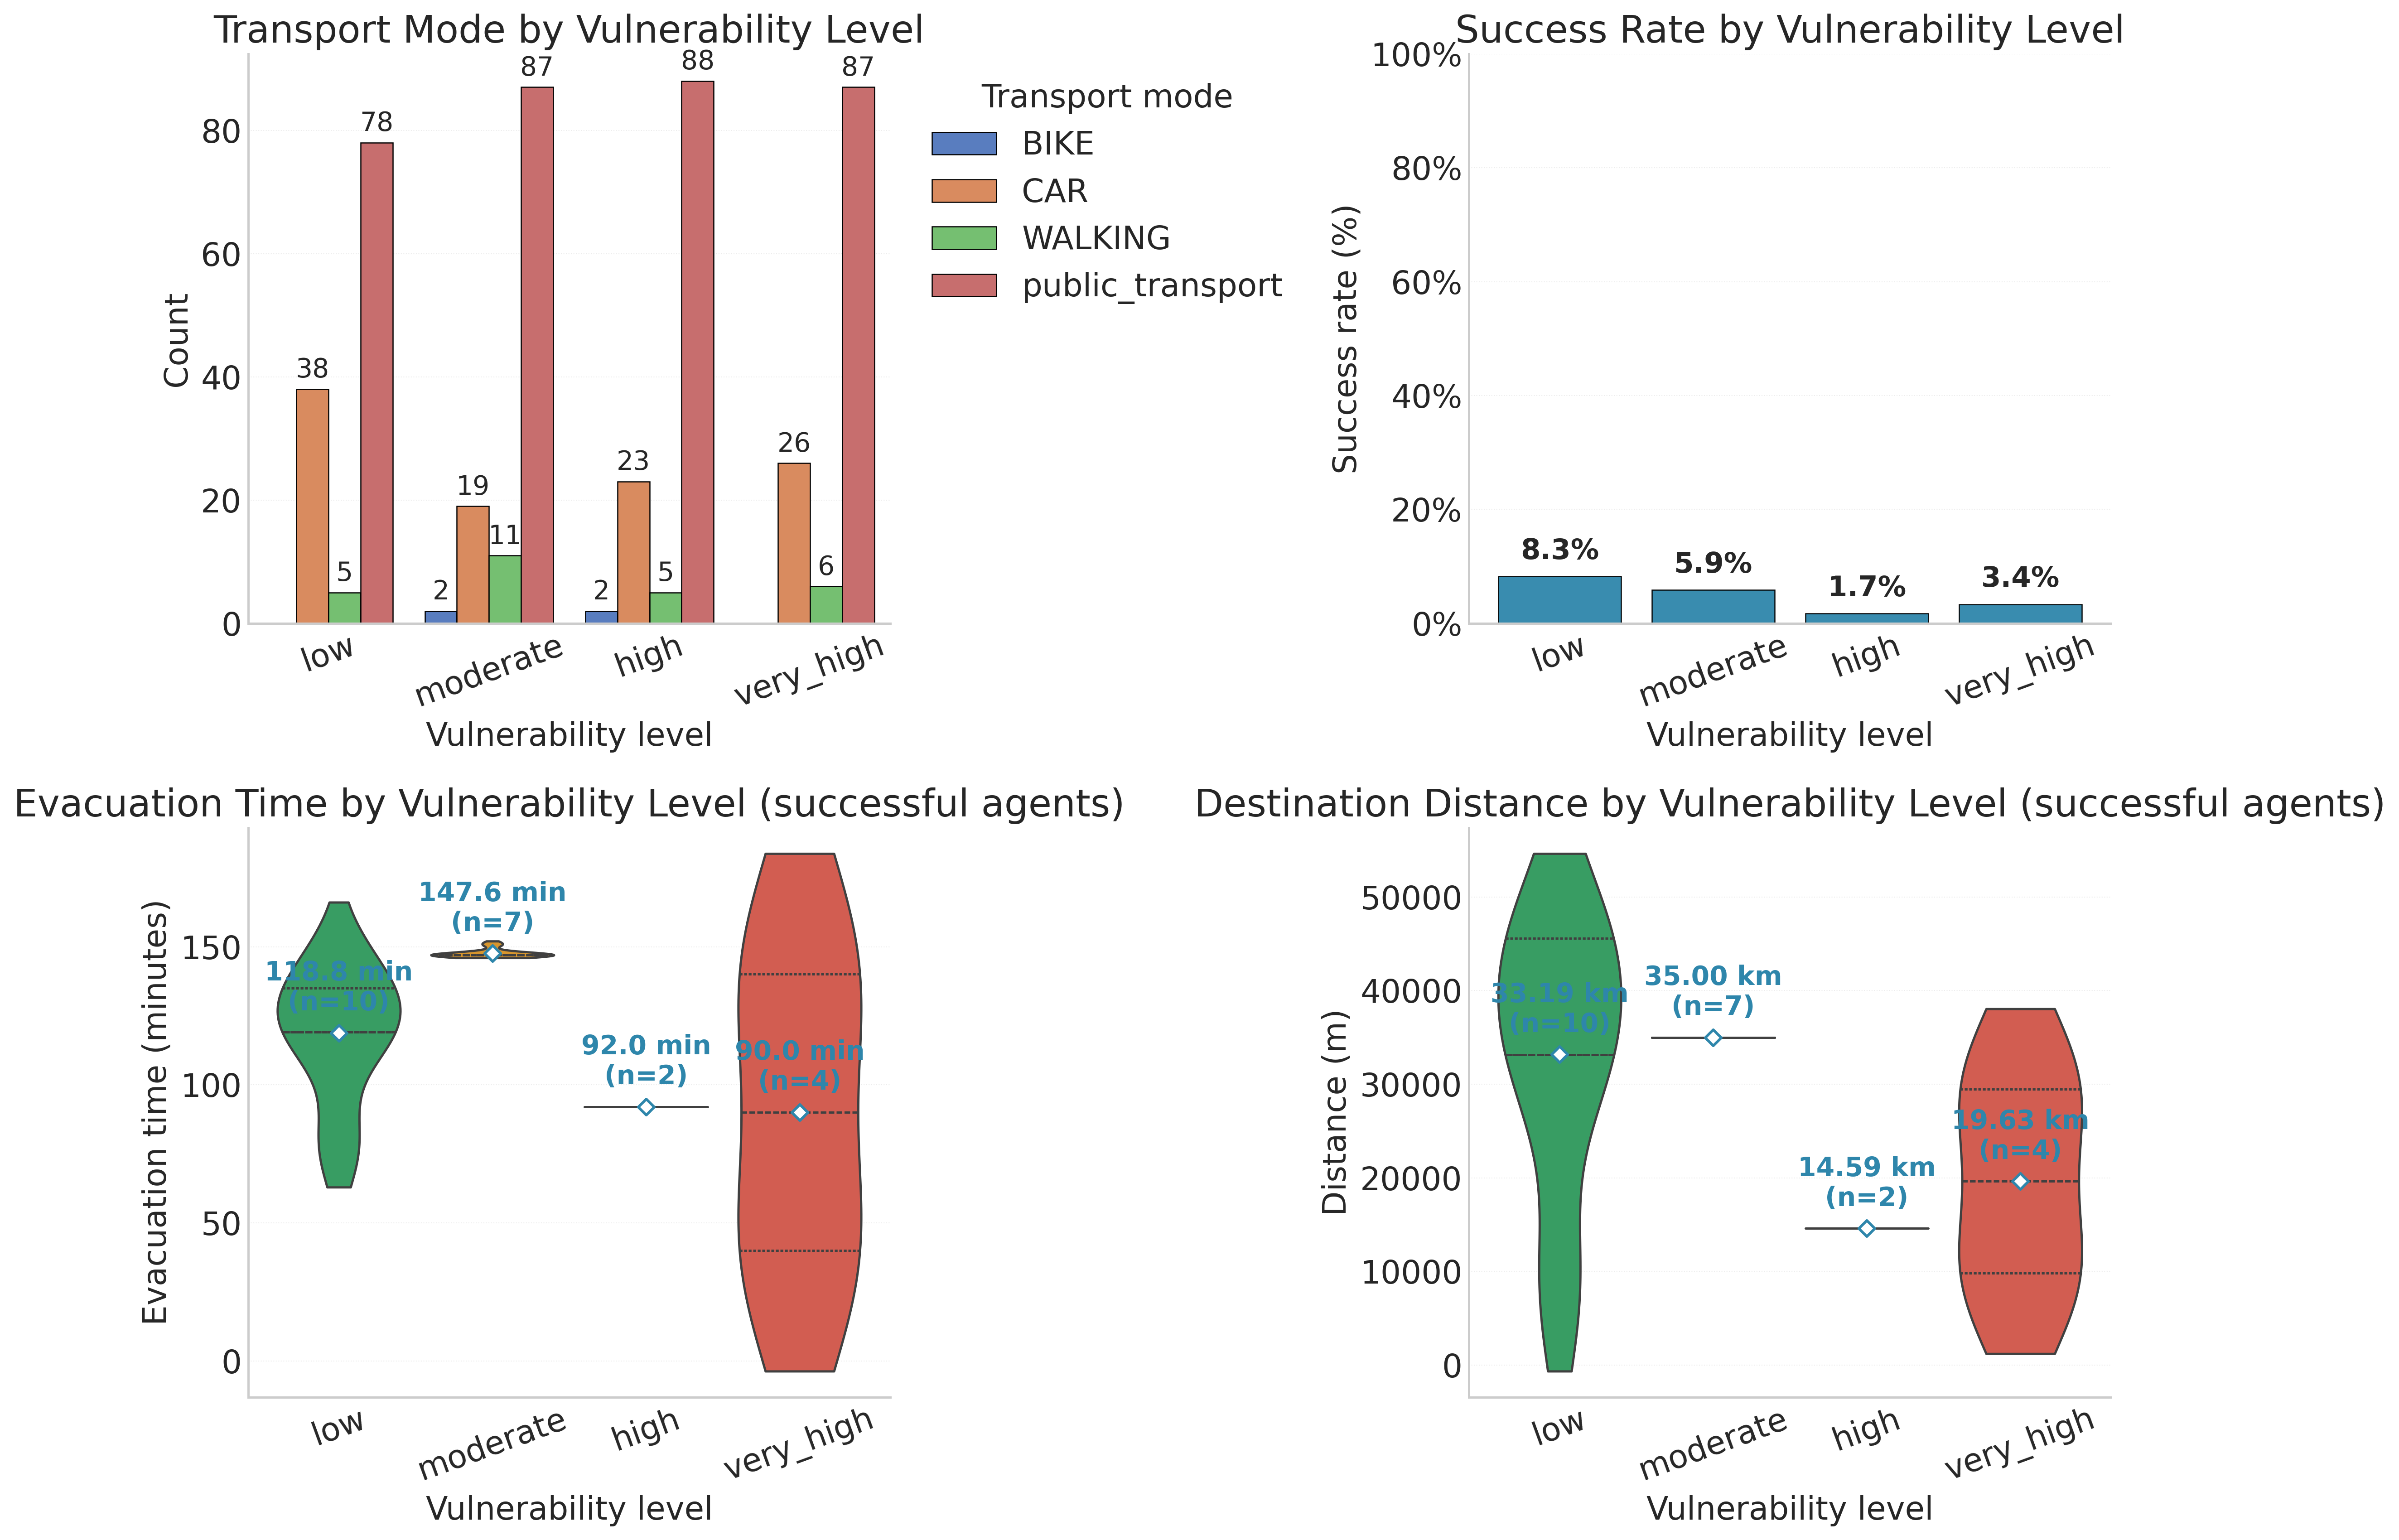

In [38]:

from typing import Optional, Sequence


def plot_svi_analysis_violin(agent_summary,
                             save_path: Optional[str] = None,
                             force_percent_ylim: bool = False,
                             figsize: tuple = (15, 12),
                             vuln_order: Sequence[str] = ("low", "moderate", "high", "very_high")):
    """
    Publication-ready SVI analysis with violin plots for time and distance.
    - agent_summary: polars.DataFrame or pandas.DataFrame
    - force_percent_ylim: if True, success rate y-axis is fixed 0-100%
    Returns (fig, axes)
    """

    # --- convert Polars -> pandas if needed ---
    if isinstance(agent_summary, pl.DataFrame):
        df = agent_summary.to_pandas()
    else:
        df = agent_summary.copy()

    # Defensive preparation
    if "vulnerability_level" not in df.columns:
        df["vulnerability_level"] = pd.Categorical(df.get("vulnerability_level", "unknown"))
    df["vulnerability_level"] = pd.Categorical(df["vulnerability_level"], categories=vuln_order, ordered=True)

    if "success" not in df.columns:
        df["success"] = False

    successful = df[df["success"].astype(bool)].copy()

    # --- figure skeleton ---
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    plt.subplots_adjust(hspace=0.28, wspace=0.22)

    # ---------------- Plot 1: Mode distribution by vulnerability (grouped bars) ----------------
    ax = axes[0, 0]
    if ("final_mode" in df.columns) and (df["final_mode"].notna().any()):
        count_df = (
            df.groupby(["vulnerability_level", "final_mode"])
            .size()
            .reset_index(name="count")
            .pivot(index="vulnerability_level", columns="final_mode", values="count")
            .fillna(0)
            .reindex(vuln_order)
        )
        long = count_df.reset_index().melt(id_vars="vulnerability_level", var_name="final_mode", value_name="count")
        total_per_mode = long.groupby("final_mode")["count"].sum()
        modes = total_per_mode[total_per_mode > 0].index.tolist()
        palette = sns.color_palette("muted", len(modes))

        sns.barplot(data=long[long["final_mode"].isin(modes)],
                    x="vulnerability_level", y="count", hue="final_mode",
                    order=vuln_order, hue_order=modes, ax=ax, palette=palette,
                    edgecolor="k", linewidth=0.6)

        ax.set_title("Transport Mode by Vulnerability Level", fontsize=TITLE_FONTSIZE)
        ax.set_ylabel("Count")
        ax.set_xlabel("Vulnerability level")
        ax.legend(title="Transport mode", bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.tick_params(axis="x", rotation=20)
        setup_academic_grid(ax, axis="y")

        # annotate counts
        for p in ax.patches:
            h = p.get_height()
            if h > 0:
                ax.text(p.get_x() + p.get_width() / 2, h + max(1, h * 0.01),
                        f"{int(h):,}", ha="center", va="bottom", fontsize=BASE_FONTSIZE - 3)
    else:
        ax.text(0.5, 0.5, "Missing 'final_mode' data", ha="center", va="center", fontsize=BASE_FONTSIZE)
        ax.set_axis_off()

    # ---------------- Plot 2: Success rate by vulnerability level ----------------
    ax = axes[0, 1]
    if "vulnerability_level" in df.columns and "success" in df.columns:
        success_stats = df.groupby("vulnerability_level")["success"].agg(["mean", "count"]).reindex(vuln_order).fillna(
            0)
        success_stats["mean_pct"] = success_stats["mean"] * 100

        bars = ax.bar(success_stats.index.astype(str), success_stats["mean_pct"],
                      color=primary_color, edgecolor="k", linewidth=0.6, alpha=0.95)

        ax.set_title("Success Rate by Vulnerability Level", fontsize=TITLE_FONTSIZE)
        ax.set_ylabel("Success rate (%)")
        ax.set_xlabel("Vulnerability level")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0))
        ax.tick_params(axis="x", rotation=20)
        setup_academic_grid(ax, axis="y")

        if force_percent_ylim:
            ax.set_ylim(0, 100)
        else:
            top = max(5, success_stats["mean_pct"].max() * 1.12)
            ax.set_ylim(0, top)

        for i, (lvl, row) in enumerate(success_stats.iterrows()):
            pct = row["mean_pct"]
            n = int(row["count"])
            ax.text(i, pct + (ax.get_ylim()[1] * 0.02), f"{pct:.1f}%",
                    ha="center", va="bottom", fontsize=BASE_FONTSIZE - 2, fontweight="bold")
    else:
        ax.text(0.5, 0.5, "Missing 'vulnerability_level' or 'success' data", ha="center", va="center",
                fontsize=BASE_FONTSIZE)
        ax.set_axis_off()

    # ---------------- Plot 3: Evacuation time — violin plots (successful agents) ----------------
    ax = axes[1, 0]
    if "evacuation_time_minutes" in successful.columns and successful.shape[0] > 0:
        present_lvls = [lvl for lvl in vuln_order if lvl in successful["vulnerability_level"].unique()]
        if not present_lvls:
            ax.text(0.5, 0.5, "No vulnerability categories found", ha="center", va="center", fontsize=BASE_FONTSIZE)
            ax.set_axis_off()
        else:
            # build palette mapping from vulnerability levels
            default_palette = sns.color_palette("pastel", len(present_lvls))
            palette_map = {lvl: VULNERABILITY_COLORS.get(lvl, default_palette[i]) for i, lvl in enumerate(present_lvls)}

            sns.violinplot(data=successful,
                           x="vulnerability_level",
                           y="evacuation_time_minutes",
                           order=present_lvls,
                           ax=ax,
                           inner="quartile",
                           palette=palette_map,
                           cut=1,
                           linewidth=1.2)

            ax.set_title("Evacuation Time by Vulnerability Level (successful agents)", fontsize=TITLE_FONTSIZE)
            ax.set_xlabel("Vulnerability level")
            ax.set_ylabel("Evacuation time (minutes)")
            ax.tick_params(axis="x", rotation=20)
            setup_academic_grid(ax, axis="y")

            # overlay mean markers and annotate
            means = successful.groupby("vulnerability_level")["evacuation_time_minutes"].mean().reindex(
                present_lvls).values
            counts = successful.groupby("vulnerability_level")["evacuation_time_minutes"].count().reindex(
                present_lvls).values
            x_positions = np.arange(len(present_lvls))

            ax.scatter(x_positions, means,
                       marker="D", s=MARKER_SIZE, edgecolor=primary_color, facecolor="white",
                       linewidth=1.4, zorder=10)

            y_min, y_max = ax.get_ylim()
            y_range = y_max - y_min
            for i, (m, n) in enumerate(zip(means, counts)):
                ax.text(x_positions[i], m + y_range * 0.03, f"{m:.1f} min\n(n={int(n)})",
                        ha="center", va="bottom", fontsize=BASE_FONTSIZE - 3, fontweight="bold", color=primary_color)
    else:
        ax.text(0.5, 0.5, "Missing 'evacuation_time_minutes' or no successful agents", ha="center", va="center",
                fontsize=BASE_FONTSIZE)
        ax.set_axis_off()

    # ---------------- Plot 4: Destination distance — violin plots (successful agents) ----------------
    ax = axes[1, 1]
    if "target_destination_distance_m" in successful.columns and successful.shape[0] > 0:
        present_lvls = [lvl for lvl in vuln_order if lvl in successful["vulnerability_level"].unique()]
        if not present_lvls:
            ax.text(0.5, 0.5, "No vulnerability categories found", ha="center", va="center", fontsize=BASE_FONTSIZE)
            ax.set_axis_off()
        else:
            default_palette = sns.color_palette("pastel", len(present_lvls))
            palette_map = {lvl: VULNERABILITY_COLORS.get(lvl, default_palette[i]) for i, lvl in enumerate(present_lvls)}

            sns.violinplot(data=successful,
                           x="vulnerability_level",
                           y="target_destination_distance_m",
                           order=present_lvls,
                           ax=ax,
                           inner="quartile",
                           palette=palette_map,
                           cut=1,
                           linewidth=1.2)

            ax.set_title("Destination Distance by Vulnerability Level (successful agents)", fontsize=TITLE_FONTSIZE)
            ax.set_xlabel("Vulnerability level")
            ax.set_ylabel("Distance (m)")
            ax.tick_params(axis="x", rotation=20)
            setup_academic_grid(ax, axis="y")

            # overlay mean markers and annotate
            means = successful.groupby("vulnerability_level")["target_destination_distance_m"].mean().reindex(
                present_lvls).values
            counts = successful.groupby("vulnerability_level")["target_destination_distance_m"].count().reindex(
                present_lvls).values
            x_positions = np.arange(len(present_lvls))

            ax.scatter(x_positions, means,
                       marker="D", s=MARKER_SIZE, edgecolor=primary_color, facecolor="white",
                       linewidth=1.4, zorder=10)

            y_min, y_max = ax.get_ylim()
            y_range = y_max - y_min
            for i, (m, n) in enumerate(zip(means, counts)):
                # display km when appropriate
                label = f"{m:.0f} m" if m < 1000 else f"{m / 1000:.2f} km"
                ax.text(x_positions[i], m + y_range * 0.03, f"{label}\n(n={int(n)})",
                        ha="center", va="bottom", fontsize=BASE_FONTSIZE - 3, fontweight="bold", color=primary_color)
    else:
        ax.text(0.5, 0.5, "Missing 'target_destination_distance_m' or no successful agents", ha="center", va="center",
                fontsize=BASE_FONTSIZE)
        ax.set_axis_off()

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if save_path:
        try:
            savefig_standard(save_path)
        except Exception:
            plt.savefig(save_path, bbox_inches="tight", dpi=DPI)
            print(f"Saved (fallback): {save_path}")

    return fig, axes


fig, axes = plot_svi_analysis_violin(agent_summary, force_percent_ylim=True)

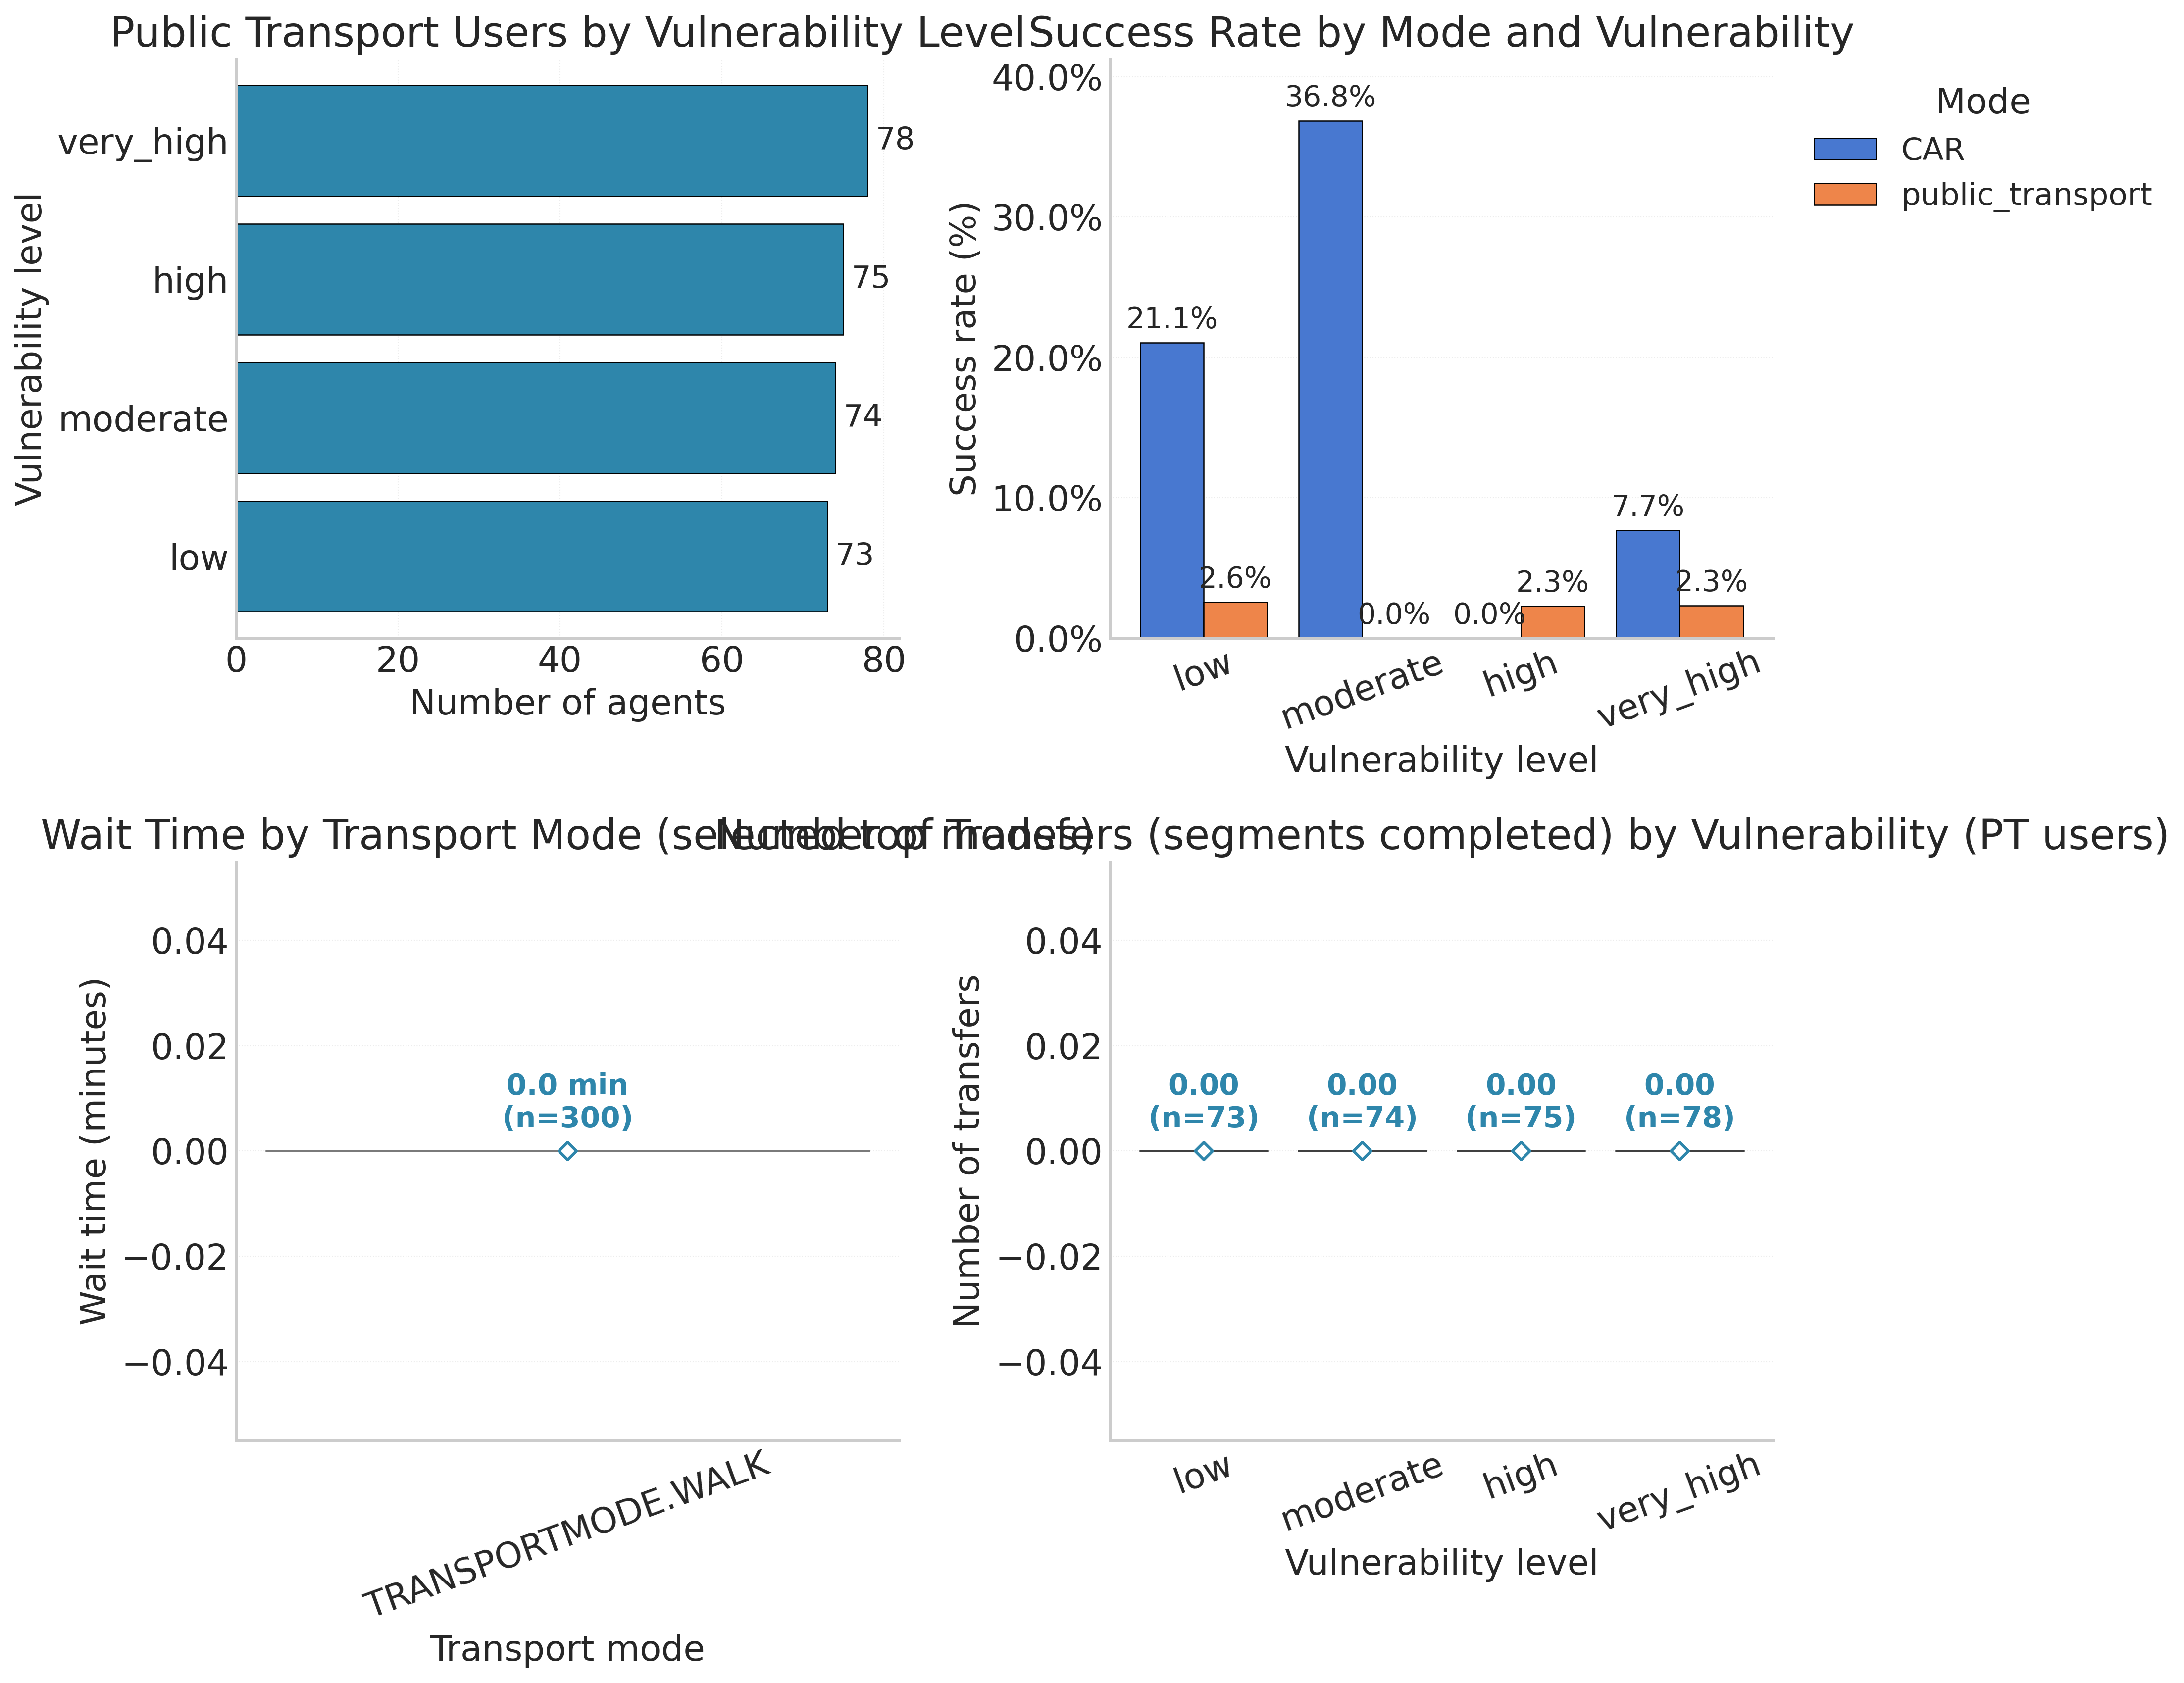

In [39]:

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from typing import Optional, Sequence


def plot_public_transport_analysis_styled(agent_summary,
                                          journey_segments,
                                          save_path: Optional[str] = None,
                                          force_percent_ylim: bool = False,
                                          figsize: tuple = (15, 12),
                                          vuln_order: Sequence[str] = ("low", "moderate", "high", "very_high")):
    """
    Publication-ready analysis of public transport usage & effectiveness.

    Parameters
    ----------
    agent_summary : polars.DataFrame or pandas.DataFrame
    journey_segments : polars.DataFrame or pandas.DataFrame
    save_path : optional path to save figure (uses savefig_standard)
    force_percent_ylim : if True, success-rate axes are 0-100%
    figsize : figure size
    vuln_order : vulnerability categories ordering
    Returns
    -------
    fig, axes
    """

    # --- Convert Polars -> pandas if needed ---
    if isinstance(agent_summary, pl.DataFrame):
        agents = agent_summary.to_pandas()
    else:
        agents = agent_summary.copy()

    if isinstance(journey_segments, pl.DataFrame):
        segments = journey_segments.to_pandas()
    else:
        segments = journey_segments.copy()

    # Prepare columns defensively
    if "vulnerability_level" not in agents.columns:
        agents["vulnerability_level"] = pd.Categorical(agents.get("vulnerability_level", "unknown"))
    agents["vulnerability_level"] = pd.Categorical(agents["vulnerability_level"], categories=vuln_order, ordered=True)

    if "used_public_transport" not in agents.columns:
        agents["used_public_transport"] = False

    # Filter PT users (safe even if column missing)
    pt_agents = agents[agents["used_public_transport"].astype(bool)].copy()

    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    plt.subplots_adjust(hspace=0.28, wspace=0.22)

    # ---------------- Panel 1: Public transport usage by vulnerability (horizontal bar) ----------------
    ax = axes[0, 0]
    if pt_agents.shape[0] > 0 and "vulnerability_level" in pt_agents.columns:
        counts = pt_agents["vulnerability_level"].value_counts().reindex(vuln_order).fillna(0)
        # horizontal bars for readability
        bars = ax.barh(counts.index.astype(str), counts.values, color=primary_color, edgecolor="k", linewidth=0.6)
        ax.set_title("Public Transport Users by Vulnerability Level", fontsize=TITLE_FONTSIZE)
        ax.set_xlabel("Number of agents")
        ax.set_ylabel("Vulnerability level")
        setup_academic_grid(ax, axis="x")
        # annotate counts
        max_val = counts.values.max() if counts.values.size > 0 else 0
        for i, (label, val) in enumerate(counts.items()):
            ax.text(val + max(1, max_val * 0.01), i, f"{int(val):,}", va="center", fontsize=BASE_FONTSIZE - 2)
    else:
        ax.text(0.5, 0.5, "No public-transport users or missing vulnerability info", ha="center", va="center",
                fontsize=BASE_FONTSIZE)
        ax.set_axis_off()

    # ---------------- Panel 2: Success rate by mode and vulnerability (grouped bars) ----------------
    ax = axes[0, 1]
    # prefer mode_category if present; fallback to final_mode/original_mode
    if "mode_category" in agents.columns:
        mode_col = "mode_category"
    elif "final_mode" in agents.columns:
        mode_col = "final_mode"
    elif "original_mode" in agents.columns:
        mode_col = "original_mode"
    else:
        mode_col = None

    if mode_col and "vulnerability_level" in agents.columns and "success" in agents.columns:
        # compute mean success per (vuln, mode)
        success_df = agents.groupby(["vulnerability_level", mode_col])["success"].mean().reset_index()
        success_df["mean_pct"] = success_df["success"] * 100.0
        pivot = success_df.pivot(index="vulnerability_level", columns=mode_col, values="mean_pct").reindex(
            vuln_order).fillna(0)

        # remove modes with all zeros (no data)
        valid_modes = pivot.columns[(pivot.sum(axis=0) > 0)].tolist()
        pivot = pivot[valid_modes]

        if pivot.shape[1] == 0:
            ax.text(0.5, 0.5, "No mode data available", ha="center", va="center", fontsize=BASE_FONTSIZE)
            ax.set_axis_off()
        else:
            x = np.arange(len(pivot.index))
            n_modes = len(valid_modes)
            width = 0.8 / max(1, n_modes)
            palette = sns.color_palette("muted", n_modes)
            for i, mode in enumerate(valid_modes):
                vals = pivot[mode].values
                ax.bar(x + (i - (n_modes - 1) / 2) * width, vals, width=width,
                       label=str(mode), color=palette[i], edgecolor="k", linewidth=0.6)
                # annotate
                for xi, v in zip(x + (i - (n_modes - 1) / 2) * width, vals):
                    ax.text(xi, v + max(0.6, ax.get_ylim()[1] * 0.01 if ax.get_ylim()[1] > 0 else 1), f"{v:.1f}%",
                            ha="center", va="bottom", fontsize=BASE_FONTSIZE - 3)

            ax.set_xticks(x)
            ax.set_xticklabels([str(v) for v in pivot.index], rotation=20)
            ax.set_ylabel("Success rate (%)")
            ax.set_xlabel("Vulnerability level")
            ax.set_title("Success Rate by Mode and Vulnerability", fontsize=TITLE_FONTSIZE)
            ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0))
            setup_academic_grid(ax, axis="y")
            if force_percent_ylim:
                ax.set_ylim(0, 100)
            else:
                top = max(5, pivot.values.max() * 1.12)
                ax.set_ylim(0, top)
            # legend
            ax.legend(title="Mode", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=BASE_FONTSIZE - 2)
    else:
        ax.text(0.5, 0.5, "Missing mode or success data", ha="center", va="center", fontsize=BASE_FONTSIZE)
        ax.set_axis_off()

    # ---------------- Panel 3: Wait times by transport mode (violin + mean/median markers) ----------------
    ax = axes[1, 0]
    if "wait_time_minutes" in segments.columns and "transport_mode" in segments.columns:
        seg = segments.dropna(subset=["wait_time_minutes", "transport_mode"]).copy()
        if seg.shape[0] == 0:
            ax.text(0.5, 0.5, "No journey_segments wait-time data", ha="center", va="center", fontsize=BASE_FONTSIZE)
            ax.set_axis_off()
        else:
            # choose top N modes by count to avoid clutter
            top_modes = seg["transport_mode"].value_counts().nlargest(6).index.tolist()
            plot_df = seg[seg["transport_mode"].isin(top_modes)].copy()
            order = top_modes

            # build palette (use neutral palette since these are modes, not vulnerabilities)
            palette = sns.color_palette("pastel", len(order))

            sns.violinplot(data=plot_df, x="transport_mode", y="wait_time_minutes",
                           order=order, ax=ax, inner="quartile", palette=palette, cut=0, linewidth=1.2)

            ax.set_title("Wait Time by Transport Mode (selected top modes)", fontsize=TITLE_FONTSIZE)
            ax.set_xlabel("Transport mode")
            ax.set_ylabel("Wait time (minutes)")
            ax.tick_params(axis="x", rotation=20)
            setup_academic_grid(ax, axis="y")

            # overlay mean markers and annotate n
            means = plot_df.groupby("transport_mode")["wait_time_minutes"].mean().reindex(order).values
            counts = plot_df["transport_mode"].value_counts().reindex(order).fillna(0).values
            x_positions = np.arange(len(order))
            ax.scatter(x_positions, means, marker="D", s=MARKER_SIZE, edgecolor=primary_color, facecolor="white",
                       linewidth=1.4, zorder=10)
            y_min, y_max = ax.get_ylim()
            y_range = y_max - y_min if y_max > y_min else 1.0
            for i, (m, n) in enumerate(zip(means, counts)):
                ax.text(x_positions[i], m + y_range * 0.03, f"{m:.1f} min\n(n={int(n)})",
                        ha="center", va="bottom", fontsize=BASE_FONTSIZE - 3, fontweight="bold", color=primary_color)
    else:
        ax.text(0.5, 0.5, "Missing 'wait_time_minutes' or 'transport_mode' in journey_segments", ha="center",
                va="center", fontsize=BASE_FONTSIZE)
        ax.set_axis_off()

    # ---------------- Panel 4: Number of transfers (segments_completed) by vulnerability (violin) ----------------
    ax = axes[1, 1]
    if "segments_completed" in pt_agents.columns and pt_agents.shape[0] > 0:
        df_pt = pt_agents.dropna(subset=["segments_completed", "vulnerability_level"]).copy()
        if df_pt.shape[0] == 0:
            ax.text(0.5, 0.5, "No segments_completed data for PT users", ha="center", va="center",
                    fontsize=BASE_FONTSIZE)
            ax.set_axis_off()
        else:
            present_lvls = [lvl for lvl in vuln_order if lvl in df_pt["vulnerability_level"].unique()]
            palette = [VULNERABILITY_COLORS.get(l, None) or sns.color_palette("pastel")[i % 8] for i, l in
                       enumerate(present_lvls)]

            sns.violinplot(data=df_pt, x="vulnerability_level", y="segments_completed",
                           order=present_lvls, ax=ax, inner="quartile", palette=palette, cut=0, linewidth=1.2)

            ax.set_title("Number of Transfers (segments completed) by Vulnerability (PT users)",
                         fontsize=TITLE_FONTSIZE)
            ax.set_xlabel("Vulnerability level")
            ax.set_ylabel("Number of transfers")
            ax.tick_params(axis="x", rotation=20)
            setup_academic_grid(ax, axis="y")

            # overlay means and counts
            means = df_pt.groupby("vulnerability_level")["segments_completed"].mean().reindex(present_lvls).values
            counts = df_pt.groupby("vulnerability_level")["segments_completed"].count().reindex(present_lvls).values
            x_positions = np.arange(len(present_lvls))
            ax.scatter(x_positions, means, marker="D", s=MARKER_SIZE, edgecolor=primary_color, facecolor="white",
                       linewidth=1.4, zorder=10)
            y_min, y_max = ax.get_ylim()
            y_range = y_max - y_min if y_max > y_min else 1.0
            for i, (m, n) in enumerate(zip(means, counts)):
                ax.text(x_positions[i], m + y_range * 0.03, f"{m:.2f}\n(n={int(n)})",
                        ha="center", va="bottom", fontsize=BASE_FONTSIZE - 3, fontweight="bold", color=primary_color)
    else:
        ax.text(0.5, 0.5, "Missing 'segments_completed' in PT users or no PT users", ha="center", va="center",
                fontsize=BASE_FONTSIZE)
        ax.set_axis_off()

    # Final layout and save
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_path:
        try:
            savefig_standard(save_path)
        except Exception:
            plt.savefig(save_path, bbox_inches="tight", dpi=DPI)
            print(f"Saved (fallback): {save_path}")

    return fig, axes


fig, axes = plot_public_transport_analysis_styled(agent_summary, journey_segments)

In [40]:
import numpy as np
import pandas as pd
from scipy import stats
import math
import warnings
import polars as pl


def _cohens_d(a, b):
    """Pooled Cohen's d"""
    na, nb = len(a), len(b)
    sa, sb = np.std(a, ddof=1), np.std(b, ddof=1)
    if na + nb - 2 <= 0:
        return np.nan
    pooled = np.sqrt(((na - 1) * sa ** 2 + (nb - 1) * sb ** 2) / (na + nb - 2))
    if pooled == 0:
        return np.nan
    return (np.mean(a) - np.mean(b)) / pooled


def _rank_biserial_from_u(U, n1, n2):
    """Rank-biserial effect size from Mann-Whitney U"""
    # Formula: R = 1 - (2U)/(n1*n2)
    return 1.0 - (2.0 * U) / (n1 * n2)


def _prop_diff_ci(p1, n1, p2, n2, alpha=0.05):
    """Normal-approx 95% CI for difference in proportions (p1-p2)"""
    diff = p1 - p2
    se = math.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    z = stats.norm.ppf(1 - alpha / 2)
    return diff, diff - z * se, diff + z * se, se


def perform_statistical_tests_improved(agent_summary, alpha: float = 0.05):
    """
    Run a battery of statistical tests and print results.

    Tests performed:
      1) Success rate difference: high SVI (high+very_high) vs low SVI (low+moderate)
         - contingency table + chi2 (or Fisher if small expected)
         - difference in proportions with 95% CI
      2) Correlation SVI vs evacuation_time_minutes (successful agents)
         - Pearson AND Spearman (reports both)
      3) Evacuation time: CAR vs PUBLIC_TRANSPORT (successful agents)
         - Shapiro normality check (informative)
         - If normal-ish and variances equal -> t-test (Welch's if variances unequal)
         - Else -> Mann-Whitney U (nonparametric)
         - Reports effect size: Cohen's d (for t) and rank-biserial (for MWU)
      4) Optional: Kruskal-Wallis across top modes (if >2 groups)
    """

    # --- Convert Polars to pandas if needed ---
    if isinstance(agent_summary, pl.DataFrame):
        df = agent_summary.to_pandas()
    else:
        df = agent_summary.copy()

    print("\nSTATISTICAL ANALYSIS RESULTS")
    print("=" * 60)

    # Ensure columns exist & preprocess
    required = ["vulnerability_level", "success", "svi", "evacuation_time_minutes", "final_mode"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        print("Warning: missing columns (some tests will be skipped):", missing)

    # Make success numeric (0/1) if it's boolean-like
    if "success" in df.columns:
        if df["success"].dtype == bool:
            df["_success_num"] = df["success"].astype(int)
        else:
            # coerce common truthy strings/ints
            df["_success_num"] = pd.to_numeric(df["success"], errors="coerce").fillna(0).astype(int)
    else:
        df["_success_num"] = 0

    # ----- Test 1: Success rate difference (high vs low) -----
    print("\n1) Success rate: high SVI (high+very_high) vs low SVI (low+moderate)")
    if "vulnerability_level" in df.columns and "_success_num" in df.columns:
        high_mask = df["vulnerability_level"].isin(["high", "very_high"])
        low_mask = df["vulnerability_level"].isin(["low", "moderate"])

        high = df.loc[high_mask, "_success_num"].dropna().astype(int)
        low = df.loc[low_mask, "_success_num"].dropna().astype(int)
        n_high, n_low = len(high), len(low)
        succ_high, succ_low = high.sum(), low.sum()

        print(f"  n_high={n_high:,}, successes_high={succ_high:,} | n_low={n_low:,}, successes_low={succ_low:,}")

        # contingency table
        table = np.array([[succ_high, n_high - succ_high],
                          [succ_low, n_low - succ_low]])
        # expected counts
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                chi2, p_chi, dof, expected = stats.chi2_contingency(table, correction=False)
            except Exception:
                chi2, p_chi, dof, expected = (np.nan, np.nan, np.nan, None)

        # Use Fisher exact if any expected < 5 or small counts
        use_fisher = False
        if expected is not None and np.any(expected < 5):
            use_fisher = True
        if n_high < 20 or n_low < 20:
            use_fisher = True

        if use_fisher:
            try:
                # Fisher expects a 2x2 table: [[a,b],[c,d]] where a=succ_high
                oddsratio, p_fisher = stats.fisher_exact(table)
                print(
                    f"  Fisher exact test p = {p_fisher:.4f} (odds ratio = {oddsratio:.3f}) [used because small expected counts]")
            except Exception as e:
                print("  Fisher exact test failed:", e)
                print(f"  Chi2 (fallback) p = {p_chi:.4f}")
        else:
            print(f"  Chi-square test: chi2={chi2:.3f}, p = {p_chi:.4f}, dof={dof}")
            # also show expected counts rounded
            if expected is not None:
                print("  Expected counts (2x2):")
                print(np.round(expected, 2))

        # difference in proportions + 95% CI (normal approx)
        p_high = succ_high / n_high if n_high > 0 else np.nan
        p_low = succ_low / n_low if n_low > 0 else np.nan
        if n_high > 0 and n_low > 0:
            diff, ci_lo, ci_hi, se = _prop_diff_ci(p_high, n_high, p_low, n_low, alpha=alpha)
            print(f"  Proportion difference (high - low) = {diff * 100:.2f} percentage points (SE={se:.4f})")
            print(f"  {100 * (1 - alpha):.1f}% CI = [{ci_lo * 100:.2f}, {ci_hi * 100:.2f}] percentage points")
        else:
            print("  Not enough data to compute proportion difference.")
    else:
        print("  Skipped: 'vulnerability_level' or 'success' missing.")

    # ----- Test 2: Correlation between SVI and evacuation time (successful agents) -----
    print("\n2) Correlation between SVI and evacuation_time_minutes (successful agents)")
    if "svi" in df.columns and "evacuation_time_minutes" in df.columns and "_success_num" in df.columns:
        successful = df[df["_success_num"].astype(bool)].dropna(subset=["svi", "evacuation_time_minutes"])
        n_corr = len(successful)
        if n_corr < 3:
            print("  Skipped: not enough successful agents with SVI & evacuation_time data.")
        else:
            x = successful["svi"].astype(float).values
            y = successful["evacuation_time_minutes"].astype(float).values
            # Pearson
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                pearson_r, pearson_p = stats.pearsonr(x, y)
            # Spearman
            spearman_rho, spearman_p = stats.spearmanr(x, y)
            print(f"  n = {n_corr:,}")
            print(f"  Pearson r = {pearson_r:.4f}, p = {pearson_p:.4e}")
            print(f"  Spearman rho = {spearman_rho:.4f}, p = {spearman_p:.4e}")
            # report simple linear regression slope (optional) for interpretability
            try:
                slope, intercept, r_val, p_val_reg, se_reg = stats.linregress(x, y)
                print(f"  Linear slope (evac_time per SVI unit) = {slope:.3f} min per SVI (p={p_val_reg:.4e})")
            except Exception:
                pass
    else:
        print("  Skipped: missing 'svi' or 'evacuation_time_minutes' or 'success'.")

    # ----- Test 3: Evacuation time difference between CAR and PUBLIC_TRANSPORT (successful agents) -----
    print("\n3) Evacuation time: CAR vs PUBLIC_TRANSPORT (successful agents)")
    if "final_mode" in df.columns and "evacuation_time_minutes" in df.columns and "_success_num" in df.columns:
        successful = df[df["_success_num"].astype(bool)]
        car = successful.loc[successful["final_mode"] == "CAR", "evacuation_time_minutes"].dropna().astype(float).values
        pt = successful.loc[successful["final_mode"] == "PUBLIC_TRANSPORT", "evacuation_time_minutes"].dropna().astype(
            float).values

        print(f"  n_car = {len(car):,}, n_public_transport = {len(pt):,}")
        if len(car) < 3 or len(pt) < 3:
            print("  Not enough data for a reliable test (need >=3 per group).")
        else:
            # Normality checks (Shapiro) - informative only
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                try:
                    sw_car = stats.shapiro(car) if len(car) <= 5000 else (None, None)
                except Exception:
                    sw_car = (None, None)
                try:
                    sw_pt = stats.shapiro(pt) if len(pt) <= 5000 else (None, None)
                except Exception:
                    sw_pt = (None, None)

            if sw_car[1] is not None:
                print(f"  Shapiro car: W={sw_car[0]:.4f}, p={sw_car[1]:.4f}")
            if sw_pt[1] is not None:
                print(f"  Shapiro pt:  W={sw_pt[0]:.4f}, p={sw_pt[1]:.4f}")

            # variance homogeneity (Levene)
            try:
                lev_stat, lev_p = stats.levene(car, pt)
                print(f"  Levene test: stat={lev_stat:.3f}, p={lev_p:.4f}")
            except Exception:
                lev_p = None

            # Decide test: if both approx normal and lev_p > alpha -> t-test, else nonparametric
            normal_like = (sw_car[1] is None or sw_car[1] > alpha) and (sw_pt[1] is None or sw_pt[1] > alpha)
            if normal_like and (lev_p is not None and lev_p > alpha):
                # Student's t-test (pooled)
                t_stat, t_p = stats.ttest_ind(car, pt, equal_var=True)
                d = _cohens_d(car, pt)
                print(f"  t-test (pooled): t={t_stat:.3f}, p={t_p:.4e}, Cohen's d = {d:.3f}")
            else:
                # Welch t if normal but unequal var, else Mann-Whitney
                if normal_like:
                    t_stat, t_p = stats.ttest_ind(car, pt, equal_var=False)
                    d = _cohens_d(car, pt)
                    print(f"  Welch t-test: t={t_stat:.3f}, p={t_p:.4e}, Cohen's d = {d:.3f}")
                else:
                    # Mann-Whitney U (two-sided)
                    U, p_mwu = stats.mannwhitneyu(car, pt, alternative="two-sided")
                    rb = _rank_biserial_from_u(U, len(car), len(pt))
                    print(f"  Mann-Whitney U: U={U:.1f}, p={p_mwu:.4e}, rank-biserial = {rb:.3f}")
                    # also report medians & IQRs

            # report descriptive stats
            def _descr(arr):
                return dict(n=len(arr), mean=np.mean(arr), sd=np.std(arr, ddof=1) if len(arr) > 1 else np.nan,
                            median=np.median(arr),
                            iqr=(np.percentile(arr, 75) - np.percentile(arr, 25)) if len(arr) > 0 else np.nan,
                            p10=np.percentile(arr, 10) if len(arr) > 0 else np.nan,
                            p90=np.percentile(arr, 90) if len(arr) > 0 else np.nan)

            d_car = _descr(car)
            d_pt = _descr(pt)
            print("  Descriptive (CAR):",
                  {k: (round(v, 2) if isinstance(v, (int, float)) and not math.isnan(v) else v) for k, v in
                   d_car.items()})
            print("  Descriptive (PUBLIC_TRANSPORT):",
                  {k: (round(v, 2) if isinstance(v, (int, float)) and not math.isnan(v) else v) for k, v in
                   d_pt.items()})
    else:
        print("  Skipped: missing 'final_mode' or 'evacuation_time_minutes' or 'success'.")

    # ----- Optional: Kruskal-Wallis across top modes for evacuation time -----
    print("\n4) Kruskal-Wallis across top transport modes (evacuation time among successful agents)")
    if "final_mode" in df.columns and "evacuation_time_minutes" in df.columns and "_success_num" in df.columns:
        successful = df[df["_success_num"].astype(bool)]
        # pick modes with >= N observations
        mode_counts = successful["final_mode"].value_counts()
        top_modes = mode_counts[mode_counts >= 10].index.tolist()  # require >=10 for reasonable test
        if len(top_modes) >= 2:
            groups = [
                successful.loc[successful["final_mode"] == m, "evacuation_time_minutes"].dropna().astype(float).values
                for m in top_modes]
            try:
                H, p_kw = stats.kruskal(*groups)
                print(f"  Kruskal-Wallis H={H:.3f}, p={p_kw:.4e} across {len(top_modes)} modes (top modes count >=10)")
            except Exception as e:
                print("  Kruskal-Wallis failed:", e)
        else:
            print("  Not enough modes with >=10 observations for Kruskal-Wallis (found modes: {})".format(
                list(mode_counts.index[:10])))
    else:
        print("  Skipped Kruskal-Wallis: missing data.")

    print("\nFinished statistical tests.\n")


# Usage
perform_statistical_tests_improved(agent_summary)



STATISTICAL ANALYSIS RESULTS

1) Success rate: high SVI (high+very_high) vs low SVI (low+moderate)
  n_high=237, successes_high=6 | n_low=240, successes_low=17
  Chi-square test: chi2=5.383, p = 0.0203, dof=1
  Expected counts (2x2):
[[ 11.43 225.57]
 [ 11.57 228.43]]
  Proportion difference (high - low) = -4.55 percentage points (SE=0.0195)
  95.0% CI = [-8.36, -0.74] percentage points

2) Correlation between SVI and evacuation_time_minutes (successful agents)
  n = 23
  Pearson r = -0.3197, p = 1.3697e-01
  Spearman rho = -0.0529, p = 8.1059e-01
  Linear slope (evac_time per SVI unit) = -85.640 min per SVI (p=1.3697e-01)

3) Evacuation time: CAR vs PUBLIC_TRANSPORT (successful agents)
  n_car = 17, n_public_transport = 0
  Not enough data for a reliable test (need >=3 per group).

4) Kruskal-Wallis across top transport modes (evacuation time among successful agents)
  Not enough modes with >=10 observations for Kruskal-Wallis (found modes: ['CAR', 'public_transport'])

Finished stat

In [41]:
def generate_summary_report(agent_summary):
    """Generate a comprehensive summary report of the simulation"""
    agent_summary = agent_summary.to_pandas()
    print("SIMULATION SUMMARY REPORT")
    print("=" * 50)
    print(f"Total agents: {len(agent_summary)}")
    print(f"Successful evacuations: {agent_summary['success'].sum()} ({agent_summary['success'].mean() * 100:.2f}%)")
    print(
        f"Average evacuation time: {agent_summary[agent_summary['success']]['evacuation_time_minutes'].mean():.2f} minutes")

    print("\nBy Vulnerability Level:")
    for level in ['low', 'moderate', 'high', 'very_high']:
        level_data = agent_summary[agent_summary['vulnerability_level'] == level]
        success_rate = level_data['success'].mean() * 100
        avg_time = level_data[level_data['success']]['evacuation_time_minutes'].mean()
        print(f"  {level}: {len(level_data)} agents, {success_rate:.2f}% success, {avg_time:.2f} min avg time")

    print("\nBy Transport Mode:")
    for mode in agent_summary['final_mode'].unique():
        mode_data = agent_summary[agent_summary['final_mode'] == mode]
        success_rate = mode_data['success'].mean() * 100
        avg_time = mode_data[mode_data['success']]['evacuation_time_minutes'].mean()
        print(f"  {mode}: {len(mode_data)} agents, {success_rate:.2f}% success, {avg_time:.2f} min avg time")


generate_summary_report(agent_summary)

SIMULATION SUMMARY REPORT
Total agents: 477
Successful evacuations: 23 (4.82%)
Average evacuation time: 120.22 minutes

By Vulnerability Level:
  low: 121 agents, 8.26% success, 118.80 min avg time
  moderate: 119 agents, 5.88% success, 147.57 min avg time
  high: 118 agents, 1.69% success, 92.00 min avg time
  very_high: 119 agents, 3.36% success, 90.00 min avg time

By Transport Mode:
  public_transport: 340 agents, 1.76% success, 103.33 min avg time
  CAR: 106 agents, 16.04% success, 126.18 min avg time
  BIKE: 4 agents, 0.00% success, nan min avg time
  WALKING: 27 agents, 0.00% success, nan min avg time
